### Statement ###

Solving the problem

$$\begin{align*}
    -k \nabla u &= v\\
    \nabla \cdot v &= 0 \\

    u &= g_D \qquad             &\text{on } \Gamma_D\\
    v &= h = (h_1,\,h_2) \qquad &\text{on } \Gamma_N,
\end{align*}
$$

where $k$ is piecewise constant with a **half-square discontinuity**:

$$
k(x, y) = \begin{cases} 1 & x < 0 \\ 10 & x \geq 0 \end{cases}
$$

The boundary conditions of $v = (v_1,\,v_2)$ on $\Gamma_N$ then translate to 

$$ \begin{align*}
    \partial_x u &= h_1 \\
    \partial_y u &= h_2
\end{align*} $$


In [88]:
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [89]:
import torch
from torch.autograd import grad
from torch.optim.lr_scheduler import ReduceLROnPlateau
import sys
sys.path.append('../..')

from src import train, utils
import src.data.cube_domain as cb
import src.models.expert_discontinuous as ed
import src.models.mlp_model as mm
import src.models.expert_chars as ec
import src.models.contact_model as cm


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

L_BOUNDS = [-1.0, -1.0]
U_BOUNDS = [1.0, 1.0]


In [90]:
# k = 1 on the left half (x < 0), k = 10 on the right half (x >= 0)
def k(x: torch.Tensor) -> torch.Tensor:
    return torch.where(x[:, 0] < 0, 10.0, 1.0).unsqueeze(1)


def g_D(x: torch.Tensor) -> torch.Tensor:
    return 0.5 * (x[:, 0:1] + 1)


def u_0(x: torch.Tensor) -> torch.Tensor:
    return 1 - x[:, 0:1]**2


def v_0(x: torch.Tensor) -> torch.Tensor:
    shape = 1 - x[:, 1:2]**2                   # (N,1), zero when y=±1
    ones  = torch.ones(x.shape[0], 1, device=x.device)
    return torch.cat([ones, shape], dim=1)       # (N,2)


def h(x: torch.Tensor) -> torch.Tensor:
    return torch.cat([torch.zeros_like(x[:, 0:1]), x[:, 1:2]], dim=1)


In [91]:
def res(u: torch.Tensor, v: torch.Tensor, pde_in: torch.Tensor):
    grad_u = grad(u, pde_in, torch.ones_like(u), create_graph=True)[0]

    res_1 = k(pde_in) * grad_u + v

    v_1_x = grad(v[:, 0], pde_in, torch.ones_like(v[:, 0]), create_graph=True)[0][:, 0]
    v_2_y = grad(v[:, 1], pde_in, torch.ones_like(v[:, 1]), create_graph=True)[0][:, 1]

    res_2 = v_1_x + v_2_y

    return res_1, res_2


In [92]:
# chi = 1 on the left half (k=1 region), 0 on the right half (k=10 region)
def chi(x):
    return torch.where(x[:, 0] < 0, 1.0, 0.0).float().unsqueeze(1)

model_ctx_u = mm.ModelContext(
    input_dim=2,
    output_dim=1,
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    layer=[32, 32, 32],
    hard_enforce=True,
    constraint_functions=(g_D, u_0)
)

model_ctx_v_exp = ec.PerCharCtx(
    input_dim=2,
    output_dim=2,
    char_functions=[lambda x: 1 - chi(x), chi],
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    hidden_layers_per_output=[[16, 16, 16], [16, 16, 16]],
    hard_enforce=True,
    constraint_functions=(h, v_0),
)

model_ctx_v_smooth = mm.ModelContext(
    input_dim=2,
    output_dim=2,
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    layer=[32, 32, 32],
    hard_enforce=True,
    constraint_functions=(h, v_0)
)

model_ctx_v_disc = mm.ModelContext(
    input_dim=2,
    output_dim=2,
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    layer=[32, 32, 32],
    hard_enforce=True,
    constraint_functions=(h, v_0),
    has_discontinuity=True,
    last_layer_activation='disc'
)

model_u_exp = mm.MLPModel(model_ctx_u).to(device)
model_u_smooth = mm.MLPModel(model_ctx_u).to(device)
model_u_disc = mm.MLPModel(model_ctx_u).to(device)

model_v_exp = ec.PerCharModel(model_ctx_v_exp).to(device)
model_v_smooth = mm.MLPModel(model_ctx_v_smooth).to(device)
model_v_disc = mm.MLPModel(model_ctx_v_disc).to(device)

model_combined_exp = ec.MultiModel(model_u_exp, model_v_exp).to(device)
model_combined_smooth = ec.MultiModel(model_u_smooth, model_v_smooth).to(device)
model_combined_disc = ec.MultiModel(model_u_disc, model_v_disc).to(device)

optim_combine_exp = torch.optim.Adam(model_combined_exp.parameters(), lr=5e-4)
optim_combine_smooth = torch.optim.Adam(model_combined_smooth.parameters(), lr=5e-4)
optim_combine_disc = torch.optim.Adam(model_combined_disc.parameters(), lr=5e-4)

sched_combine_exp = ReduceLROnPlateau(optim_combine_exp, factor=0.75, patience=2_000)
sched_combine_smooth = ReduceLROnPlateau(optim_combine_smooth, factor=0.75, patience=2_000)
sched_combine_disc = ReduceLROnPlateau(optim_combine_disc, factor=0.75, patience=2_000)


In [93]:
model_v1 = mm.MLPModel(model_ctx_v_smooth).to(device)
model_v2 = mm.MLPModel(model_ctx_v_smooth).to(device)

# phi > 0 on the left half (chi=1, k=1 region): phi = -x
def phi(x):
    return -x[:, 0:1]

model_ctx_contact = cm.ContactModelCtx(
    model_1=model_v1,
    model_2=model_v2,
    k_1=10.0,   # right half (chi=0)
    k_2=1.0,    # left half  (chi=1)
    char_func=chi,
    region_2_boundary=phi,
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
)

model_v_contact = cm.ContactModel(model_ctx_contact).to(device)
model_u_contact = mm.MLPModel(model_ctx_u).to(device)
model_combined_contact = ec.MultiModel(model_u_contact, model_v_contact).to(device)

optim_combine_contact = torch.optim.Adam(model_combined_contact.parameters(), lr=5e-4)


In [94]:
import copy

model_init_exp    = copy.deepcopy(model_combined_exp)
model_init_disc   = copy.deepcopy(model_combined_disc)
model_init_smooth = copy.deepcopy(model_combined_smooth)

print("Initial parameter snapshots saved for all three models.")


Initial parameter snapshots saved for all three models.


In [95]:
def loss_combined(model: torch.nn.Module, domain: cb.CubeDomain):
    pde_in = domain.interior.requires_grad_(True)

    pde_out = model(pde_in)
    u = pde_out[:, 0]
    v = pde_out[:, 1:]

    res_1, res_2 = res(u, v, pde_in)
    res_sq = res_1[:, 0]**2 + res_1[:, 1]**2

    loss_1 = torch.mean(res_sq)
    loss_2 = torch.mean(res_2**2)

    return [loss_1, loss_2]


In [96]:
domain_ctx = cb.CubeContext(
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    dim=2,
    N_int=10_000,
    N_sides=[(0, 0), (0, 0)],
    int_sampling='Latin',
    device=device,
)

domain = cb.CubeDomain(domain_ctx)
print(f"Interior points: {domain.interior.shape}")


Interior points: torch.Size([10000, 2])


In [97]:
train_ctx_combined = train.TrainingContext(
    model=model_combined_exp,
    domain=domain,
    optimizer=optim_combine_exp,
    loss_fn=loss_combined,
    scheduler=sched_combine_exp,
    epochs=120_000,
    monitor_gradient=True,
    monitor_lr=True,
)

loss_exp, loss_comps_exp = train.train_switch_to_lbfgs(train_ctx_combined, lbfgs_lr=0.1, epochs_with_lbfgs=1_000)

train_ctx_combined.model = model_combined_disc
train_ctx_combined.optimizer = optim_combine_disc
train_ctx_combined.scheduler = sched_combine_disc
loss_disc, loss_comps_disc = train.train_switch_to_lbfgs(train_ctx_combined, lbfgs_lr=0.1, epochs_with_lbfgs=1_000)

train_ctx_combined.model = model_combined_smooth
train_ctx_combined.optimizer = optim_combine_smooth
train_ctx_combined.scheduler = sched_combine_smooth
loss_smooth, loss_comps_smooth = train.train_switch_to_lbfgs(train_ctx_combined, lbfgs_lr=0.1, epochs_with_lbfgs=1_000)


Loss at epoch 1 is: 12.242591857910156. Total gradient norm: nan Current learing rate: 0.0005 


Loss at epoch 100 is: 0.8601779937744141. Total gradient norm: 1.5076944255161575 Current learing rate: 0.0005 
Loss at epoch 200 is: 0.43090930581092834. Total gradient norm: 0.5559819891544315 Current learing rate: 0.0005 
Loss at epoch 300 is: 0.3325091600418091. Total gradient norm: 0.35229293243260734 Current learing rate: 0.0005 
Loss at epoch 400 is: 0.271901935338974. Total gradient norm: 0.23136158216168465 Current learing rate: 0.0005 
Loss at epoch 500 is: 0.23311308026313782. Total gradient norm: 0.134168600375472 Current learing rate: 0.0005 
Loss at epoch 600 is: 0.21488910913467407. Total gradient norm: 0.10083401699114791 Current learing rate: 0.0005 
Loss at epoch 700 is: 0.20144745707511902. Total gradient norm: 0.08829945963964958 Current learing rate: 0.0005 
Loss at epoch 800 is: 0.18679754436016083. Total gradient norm: 0.0976005608820101 Current learing rate: 0.0005 
Loss at epoch 900 is: 0.17840081453323364. Total gradient norm: 0.0643329228904135 Current learin

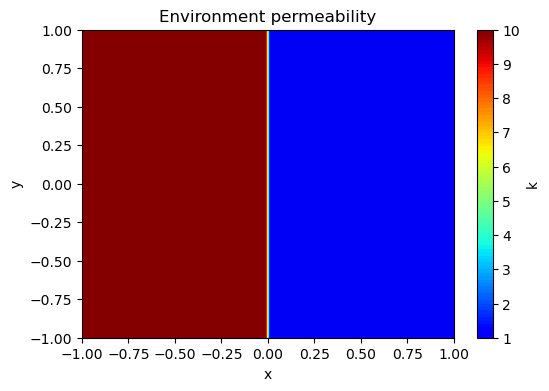

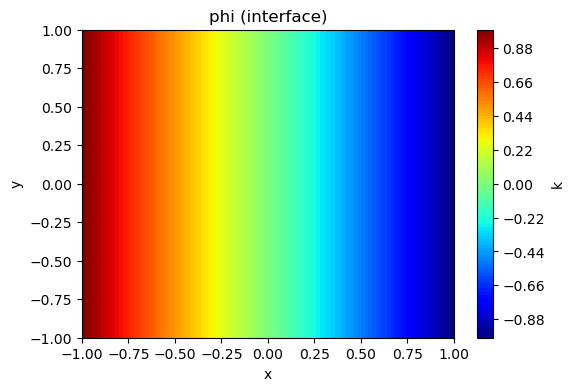

In [98]:
import os
os.makedirs("./images_hs", exist_ok=True)

def pde_residuum(pde_input: torch.Tensor, model: torch.nn.Module) -> torch.Tensor:
    u = model(pde_input)[:, 0]
    u_grad = grad(u, pde_input, torch.ones_like(u), create_graph=True)[0]
    u_x, u_y = u_grad[:, 0], u_grad[:, 1]

    u_xx = grad(u_x, pde_input, torch.ones_like(u_x), create_graph=True)[0][:, 0:1]
    u_yy = grad(u_y, pde_input, torch.ones_like(u_y), create_graph=True)[0][:, 1:2]

    return (u_xx + u_yy)

plot_ctx = utils.PlotContext(
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    patches=[],
    titles=["Environment permeability"],
    function_names=["k"],
    colour_map='jet',
    vmin=0,
    vmax=10,
    device=device,
    N=100,
    save_img=True,
)

utils.plot_function_on_2d_cube([k], plot_ctx)

plot_ctx.vmax = 1.0
plot_ctx.vmin = -1.0
plot_ctx.titles = ["phi (interface)"]
utils.plot_function_on_2d_cube([phi], plot_ctx)


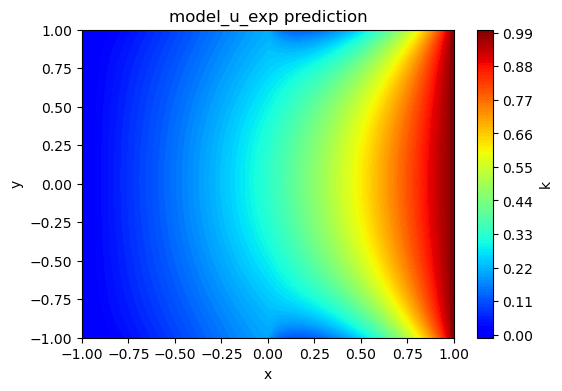

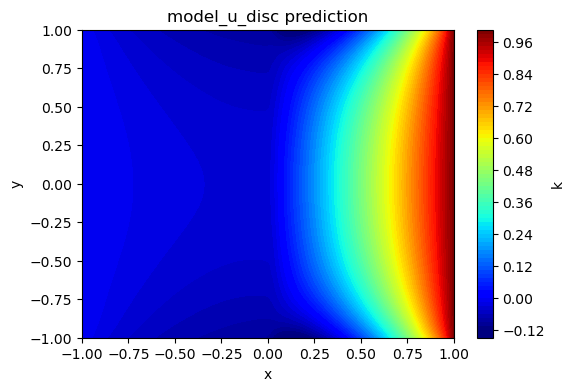

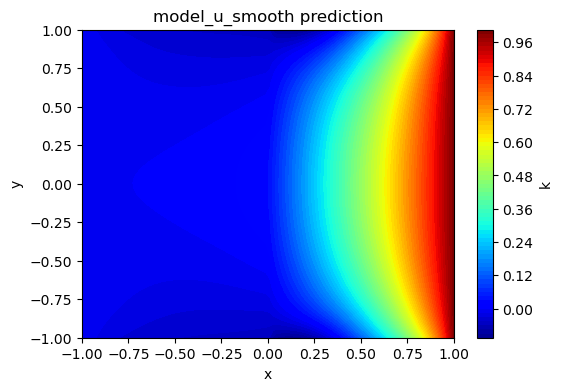

In [99]:
plot_ctx.vmin = -0.12
plot_ctx.vmax = 1

plot_ctx.titles = ['model_u_exp prediction']
plot_ctx.save_path = "./images_hs/model_u_exp_pred.png"
utils.plot_function_on_2d_cube([lambda x: model_combined_exp(x)[:, 0]], plot_ctx)

plot_ctx.titles = ['model_u_disc prediction']
plot_ctx.save_path = "./images_hs/model_u_disc_pred.png"
utils.plot_function_on_2d_cube([lambda x: model_combined_disc(x)[:, 0]], plot_ctx)

plot_ctx.titles = ['model_u_smooth prediction']
plot_ctx.save_path = "./images_hs/model_u_smooth_pred.png"
utils.plot_function_on_2d_cube([lambda x: model_combined_smooth(x)[:, 0]], plot_ctx)


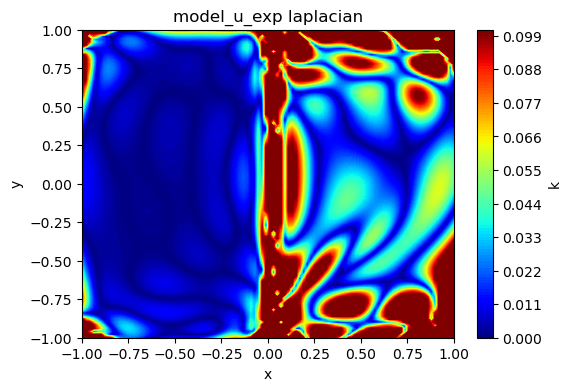

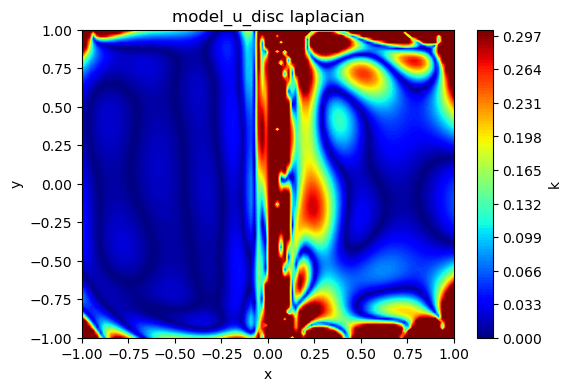

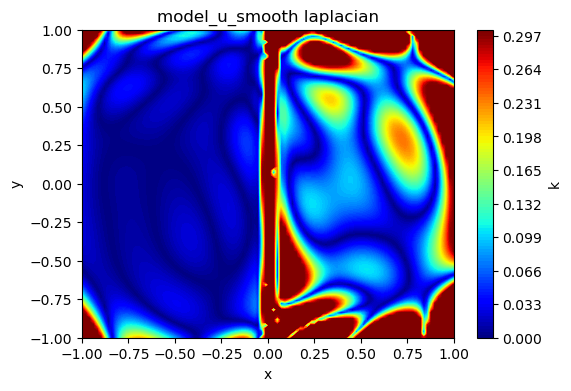

In [100]:
plot_ctx.vmax = 0.1
plot_ctx.vmin = 0.0

plot_ctx.titles = ["model_u_exp laplacian"]
plot_ctx.save_path = "./images_hs/model_u_exp_laplacian.png"
utils.plot_function_on_2d_cube([lambda x: torch.clamp(torch.abs(pde_residuum(x.requires_grad_(True), model_combined_exp)), 0.0, 0.1)], plot_ctx)

plot_ctx.vmax = 0.3
plot_ctx.titles = ["model_u_disc laplacian"]
plot_ctx.save_path = "./images_hs/model_u_disc_laplacian.png"
utils.plot_function_on_2d_cube([lambda x: torch.clamp(torch.abs(pde_residuum(x.requires_grad_(True), model_combined_disc)), 0.0, 0.3)], plot_ctx)

plot_ctx.titles = ["model_u_smooth laplacian"]
plot_ctx.save_path = "./images_hs/model_u_smooth_laplacian.png"
utils.plot_function_on_2d_cube([lambda x: torch.clamp(torch.abs(pde_residuum(x.requires_grad_(True), model_combined_smooth)), 0.0, 0.3)], plot_ctx)


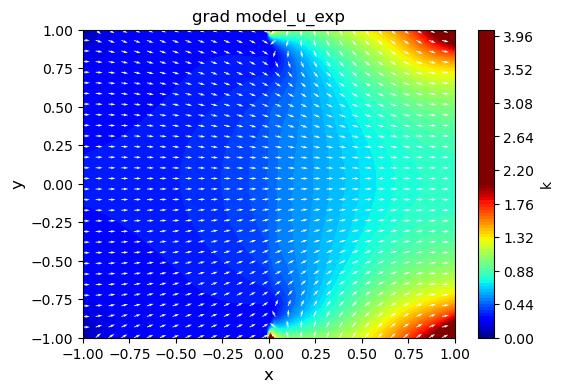

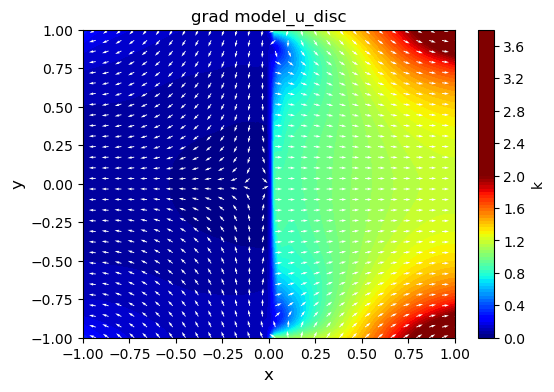

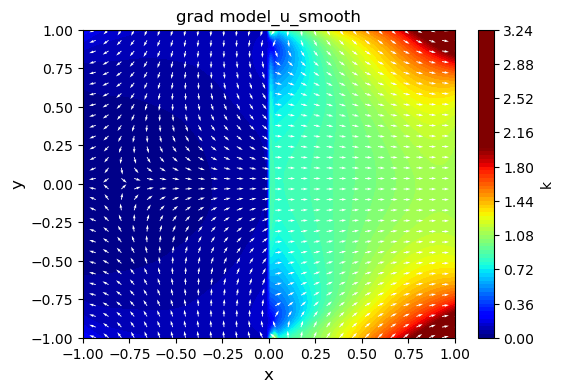

In [101]:
plot_ctx.vmin = 0
plot_ctx.vmax = 2

def heat_flow(x, model):
    x.requires_grad_(True)
    u = model(x)[:, 0]
    return grad(u, x, torch.ones_like(u))[0]

plot_ctx.titles = ['grad model_u_exp']
plot_ctx.save_path = "./images_hs/model_u_exp_grad.png"
utils.plot_vector_field_2d([lambda x: heat_flow(x, model_combined_exp)], plot_ctx, N=100, n_heigth=30, n_width=30)

plot_ctx.titles = ['grad model_u_disc']
plot_ctx.save_path = "./images_hs/model_u_disc_grad.png"
utils.plot_vector_field_2d([lambda x: heat_flow(x, model_combined_disc)], plot_ctx, N=100, n_heigth=30, n_width=30)

plot_ctx.titles = ['grad model_u_smooth']
plot_ctx.save_path = "./images_hs/model_u_smooth_grad.png"
utils.plot_vector_field_2d([lambda x: heat_flow(x, model_combined_smooth)], plot_ctx, N=100, n_heigth=30, n_width=30)


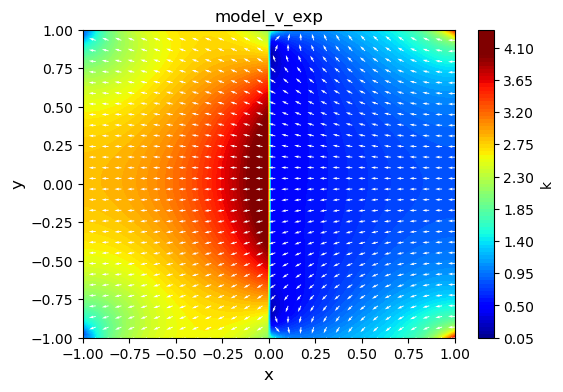

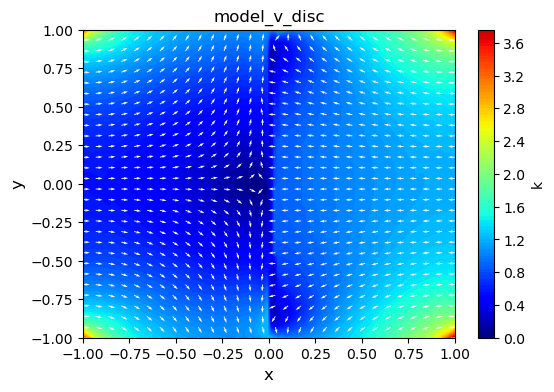

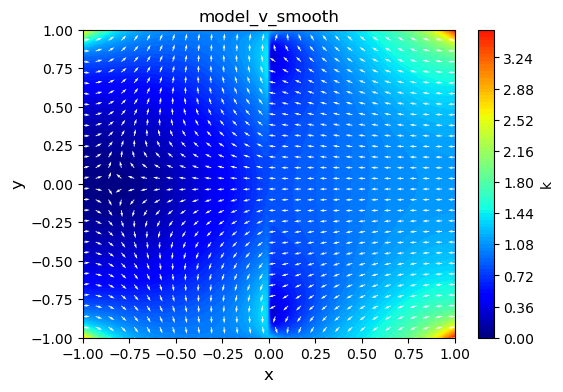

In [102]:
plot_ctx.vmin = 0
plot_ctx.vmax = 4

plot_ctx.titles = ['model_v_exp']
plot_ctx.save_path = "./images_hs/model_v_exp.png"
utils.plot_vector_field_2d([lambda x: model_combined_exp(x)[:, 1:]], plot_ctx, N=100, n_heigth=30, n_width=30)

plot_ctx.titles = ['model_v_disc']
plot_ctx.save_path = "./images_hs/model_v_disc.png"
utils.plot_vector_field_2d([lambda x: model_combined_disc(x)[:, 1:]], plot_ctx, N=100, n_heigth=30, n_width=30)

plot_ctx.titles = ['model_v_smooth']
plot_ctx.save_path = "./images_hs/model_v_smooth.png"
utils.plot_vector_field_2d([lambda x: model_combined_smooth(x)[:, 1:]], plot_ctx, N=100, n_heigth=30, n_width=30)


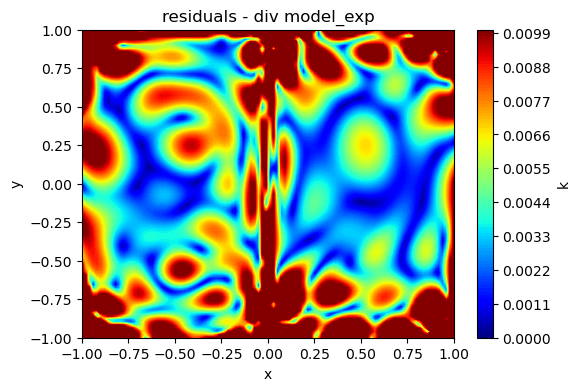

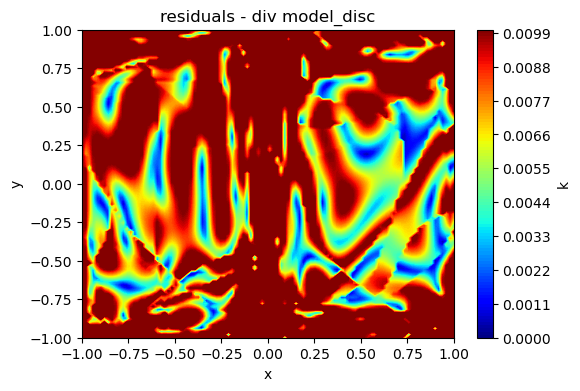

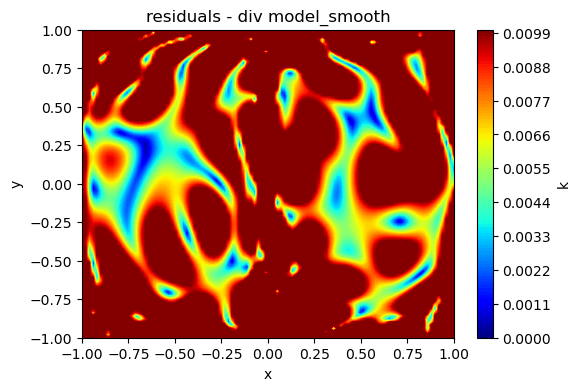

In [103]:
plot_ctx.vmax = 0.01
plot_ctx.vmin = 0.0

def res_div_helper(x, model):
    x.requires_grad_(True)
    out = model(x)
    u = out[:, 0]
    v = out[:, 1:]
    res_1, res_2 = res(u, v, x)
    return torch.norm(res_1, p=2, dim=1)

plot_ctx.titles = ["residuals - div model_exp"]
plot_ctx.save_path = "./images_hs/model_v_exp_div.png"
utils.plot_function_on_2d_cube([lambda x: torch.clamp(torch.abs(res_div_helper(x, model_combined_exp)), 0.0, 0.01)], plot_ctx)

plot_ctx.titles = ["residuals - div model_disc"]
plot_ctx.save_path = "./images_hs/model_v_disc_div.png"
utils.plot_function_on_2d_cube([lambda x: torch.clamp(torch.abs(res_div_helper(x, model_combined_disc)), 0.0, 0.01)], plot_ctx)

plot_ctx.titles = ["residuals - div model_smooth"]
plot_ctx.save_path = "./images_hs/model_v_smooth_div.png"
utils.plot_function_on_2d_cube([lambda x: torch.clamp(torch.abs(res_div_helper(x, model_combined_smooth)), 0.0, 0.01)], plot_ctx)


In [104]:
from src.calculus import L2_norm

zero_2d = lambda x: torch.zeros(x.shape[0], 2, device=x.device)
zero_1d = lambda x: torch.zeros(x.shape[0], 1, device=x.device)

def make_res1_fn(model):
    def f(x):
        x = x.requires_grad_(True)
        out = model(x)
        u, v = out[:, 0], out[:, 1:]
        r1, _ = res(u, v, x)
        return r1  # (N, 2)
    return f

def make_res2_fn(model):
    def f(x):
        x = x.requires_grad_(True)
        out = model(x)
        u, v = out[:, 0], out[:, 1:]
        _, r2 = res(u, v, x)
        return r2.unsqueeze(1)  # (N, 1)
    return f

models_named = {
    "combined_exp":    model_combined_exp,
    "combined_disc":   model_combined_disc,
    "combined_smooth": model_combined_smooth,
}

print(f"{'Model':<20}  {'L2 ||res1||':>12}  {'L2 ||res2||':>12}")
print("-" * 48)
for name, model in models_named.items():
    l2_r1 = L2_norm(make_res1_fn(model), zero_2d, input_dim=2, u_bounds=U_BOUNDS, l_bounds=L_BOUNDS, device=str(device), n=50)
    l2_r2 = L2_norm(make_res2_fn(model), zero_1d, input_dim=2, u_bounds=U_BOUNDS, l_bounds=L_BOUNDS, device=str(device), n=50)
    print(f"{name:<20}  {l2_r1.item():>12.6e}  {l2_r2.item():>12.6e}")


Model                  L2 ||res1||   L2 ||res2||
------------------------------------------------
combined_exp          4.218277e-02  1.024649e-02
combined_disc         8.197301e-02  2.334311e-02
combined_smooth       9.050866e-02  1.888883e-02


/home/berva/Projects2/Projects/PINNs/Introduction/notebooks/darcy/../../src/utils.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_x_labels)
/home/berva/Projects2/Projects/PINNs/Introduction/notebooks/darcy/../../src/utils.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_x_labels)
/home/berva/Projects2/Projects/PINNs/Introduction/notebooks/darcy/../../src/utils.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_x_labels)


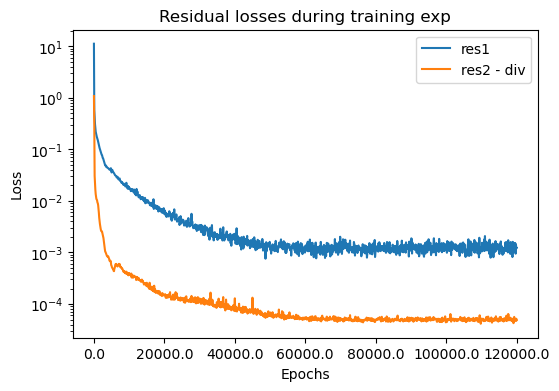

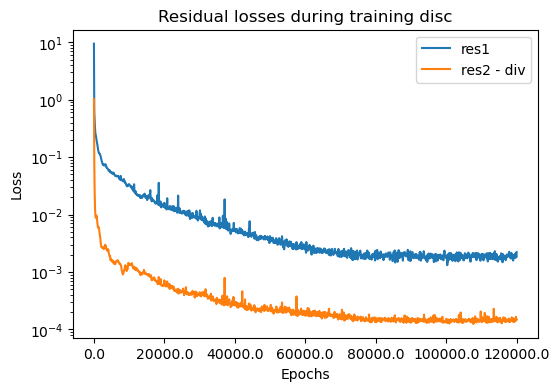

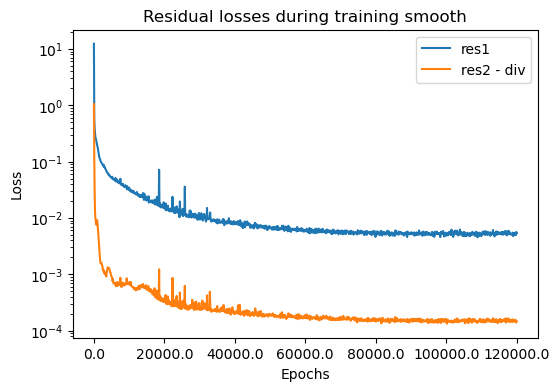

In [105]:
plot_ctx.y_label = 'Loss'
plot_ctx.x_label = 'Epochs'

plot_ctx.titles = ['Residual losses during training exp']
plot_ctx.save_path = "./images_hs/model_exp_losses.png"
utils.plot_loss_values({"res1": loss_comps_exp[0],
                        "res2 - div": loss_comps_exp[1]}, plot_ctx)

plot_ctx.titles = ['Residual losses during training disc']
plot_ctx.save_path = "./images_hs/model_disc_losses.png"
utils.plot_loss_values({"res1": loss_comps_disc[0],
                        "res2 - div": loss_comps_disc[1]}, plot_ctx)

plot_ctx.titles = ['Residual losses during training smooth']
plot_ctx.save_path = "./images_hs/model_smooth_losses.png"
utils.plot_loss_values({"res1": loss_comps_smooth[0],
                        "res2 - div": loss_comps_smooth[1]}, plot_ctx)


In [107]:
import h5py
import numpy as np
import torch
import matplotlib.pyplot as plt

# ── Load FEM reference solution ──────────────────────────────────────────────
with h5py.File("darcy_half_square_solution.h5", "r") as f:
    xy_np    = f["samples/xy"][:]           # (N, 2)
    u_fem    = f["samples/u_interp"][:]     # (N,)
    v_fem_np = f["samples/flux_interp"][:]  # (N, 2)  — v = -k ∇u from FEM

xy_fem  = torch.tensor(xy_np,    dtype=torch.float32, device=device)
u_fem_t = torch.tensor(u_fem,    dtype=torch.float32, device=device)
v_fem_t = torch.tensor(v_fem_np, dtype=torch.float32, device=device)

models = {
    "combined_exp":    model_combined_exp,
    "combined_disc":   model_combined_disc,
    "combined_smooth": model_combined_smooth,
}

u_true_norm  = torch.linalg.vector_norm(u_fem_t, ord=2)
v_true_norm  = torch.linalg.vector_norm(v_fem_t.reshape(-1), ord=2)
vx_true_norm = torch.linalg.vector_norm(v_fem_t[:, 0], ord=2)
vy_true_norm = torch.linalg.vector_norm(v_fem_t[:, 1], ord=2)

# ── Error metrics ────────────────────────────────────────────────────────────
header = (f"{'Model':<20}  {'u L2':>10}  {'u RelL2':>10}  {'u RMSE':>10}"
          f"  {'v L2':>10}  {'v RelL2':>10}  {'v RMSE':>10}"
          f"  {'vx L2':>10}  {'vx RelL2':>10}  {'vx RMSE':>10}"
          f"  {'vy L2':>10}  {'vy RelL2':>10}  {'vy RMSE':>10}")
print(header)
print("-" * len(header))

u_err_maps  = {}
v_err_maps  = {}
vx_err_maps = {}
vy_err_maps = {}

for name, model in models.items():
    model.eval()
    with torch.no_grad():
        out    = model(xy_fem)
        u_pred = out[:, 0]
        v_pred = out[:, 1:]

        u_err     = (u_pred - u_fem_t).abs()
        u_l2      = torch.linalg.vector_norm(u_err, ord=2)
        u_rel_l2  = u_l2 / (u_true_norm + 1e-12)
        u_rmse    = torch.sqrt(torch.mean((u_pred - u_fem_t)**2))

        v_err_mag = torch.norm(v_pred - v_fem_t, dim=1, p=2)
        v_l2      = torch.linalg.vector_norm(v_err_mag, ord=2)
        v_rel_l2  = v_l2 / (v_true_norm + 1e-12)
        v_rmse    = torch.sqrt(torch.mean((v_pred - v_fem_t)**2))

        vx_err    = (v_pred[:, 0] - v_fem_t[:, 0]).abs()
        vx_l2     = torch.linalg.vector_norm(vx_err, ord=2)
        vx_rel_l2 = vx_l2 / (vx_true_norm + 1e-12)
        vx_rmse   = torch.sqrt(torch.mean((v_pred[:, 0] - v_fem_t[:, 0])**2))

        vy_err    = (v_pred[:, 1] - v_fem_t[:, 1]).abs()
        vy_l2     = torch.linalg.vector_norm(vy_err, ord=2)
        vy_rel_l2 = vy_l2 / (vy_true_norm + 1e-12)
        vy_rmse   = torch.sqrt(torch.mean((v_pred[:, 1] - v_fem_t[:, 1])**2))

    u_err_maps[name]  = u_err.cpu().numpy()
    v_err_maps[name]  = v_err_mag.cpu().numpy()
    vx_err_maps[name] = vx_err.cpu().numpy()
    vy_err_maps[name] = vy_err.cpu().numpy()

    print(f"{name:<20}  {u_l2.item():>10.4e}  {u_rel_l2.item():>10.4e}  {u_rmse.item():>10.4e}"
          f"  {v_l2.item():>10.4e}  {v_rel_l2.item():>10.4e}  {v_rmse.item():>10.4e}"
          f"  {vx_l2.item():>10.4e}  {vx_rel_l2.item():>10.4e}  {vx_rmse.item():>10.4e}"
          f"  {vy_l2.item():>10.4e}  {vy_rel_l2.item():>10.4e}  {vy_rmse.item():>10.4e}")


Model                       u L2     u RelL2      u RMSE        v L2     v RelL2      v RMSE       vx L2    vx RelL2     vx RMSE       vy L2    vy RelL2     vy RMSE
--------------------------------------------------------------------------------------------------------------------------------------------------------------------
combined_exp          1.6089e+01  4.3713e-01  1.6089e-01         nan         nan         nan         nan         nan         nan         nan         nan         nan
combined_disc         3.4403e+00  9.3471e-02  3.4403e-02         nan         nan         nan         nan         nan         nan         nan         nan         nan
combined_smooth       1.4039e-01  3.8144e-03  1.4039e-03         nan         nan         nan         nan         nan         nan         nan         nan         nan


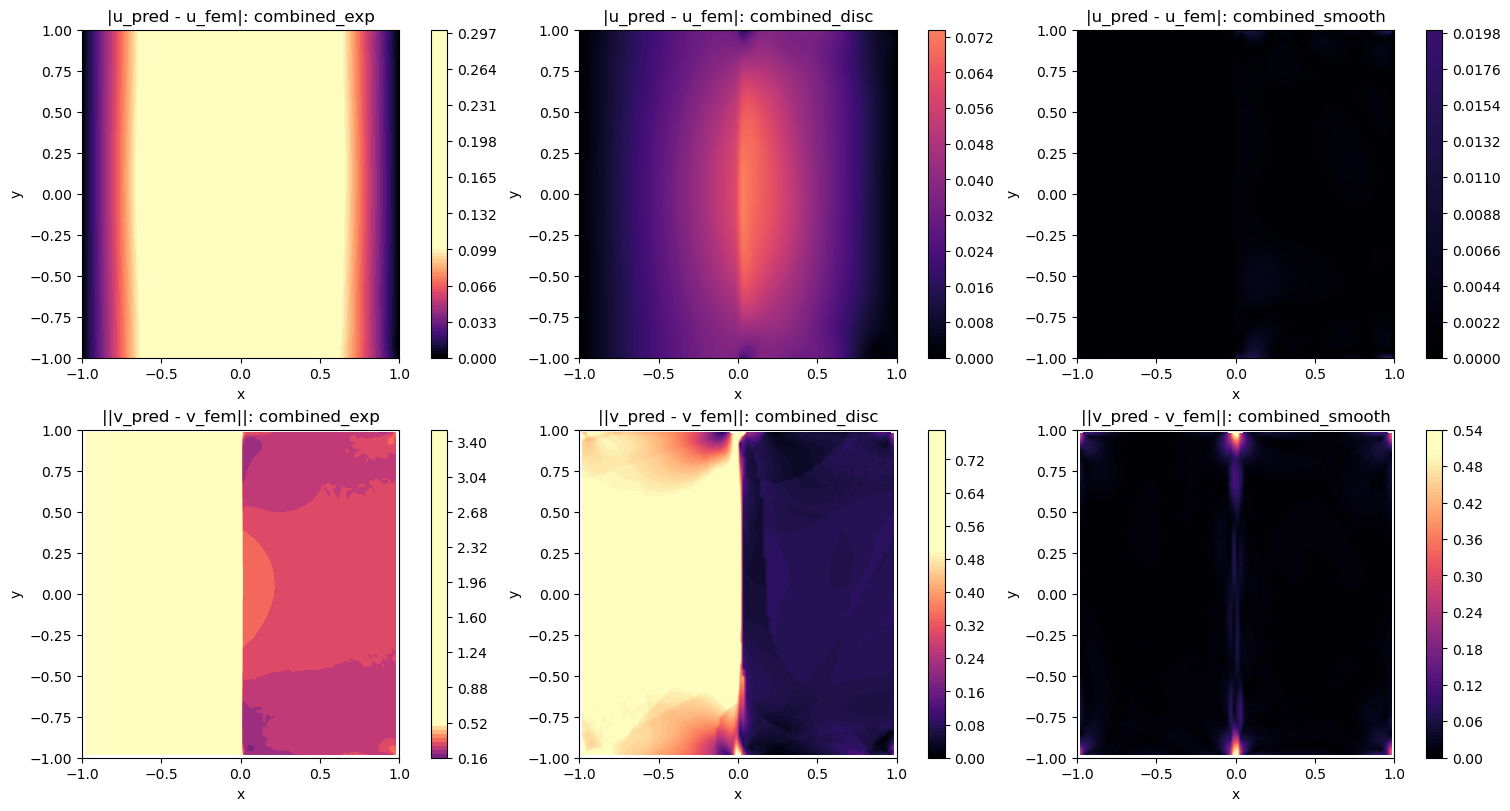

In [108]:
# ── Plot error maps: u and ||v|| ─────────────────────────────────────────────
xs = np.unique(xy_np[:, 0])
ys = np.unique(xy_np[:, 1])
nx, ny = len(xs), len(ys)
X = xy_np[:, 0].reshape(nx, ny)
Y = xy_np[:, 1].reshape(nx, ny)

n_models = len(models)

fig, axes = plt.subplots(2, n_models, figsize=(5 * n_models, 8), constrained_layout=True)

for col, name in enumerate(models.keys()):
    ax = axes[0, col]
    E = u_err_maps[name].reshape(nx, ny)
    c = ax.contourf(X, Y, E, levels=100, cmap="magma", vmin=0.0, vmax=0.1)
    ax.set_title(f"|u_pred - u_fem|: {name}")
    ax.set_xlabel("x"); ax.set_ylabel("y")
    fig.colorbar(c, ax=ax)

    ax2 = axes[1, col]
    V = v_err_maps[name].reshape(nx, ny)
    c2 = ax2.contourf(X, Y, V, levels=100, cmap="magma", vmin=0.0, vmax=0.5)
    ax2.set_title(f"||v_pred - v_fem||: {name}")
    ax2.set_xlabel("x"); ax2.set_ylabel("y")
    fig.colorbar(c2, ax=ax2)

plt.savefig("./images_hs/model_errors_uv.png")
plt.show()


In [ ]:
# ── Plot error maps: vx and vy components ────────────────────────────────────
fig, axes = plt.subplots(2, n_models, figsize=(5 * n_models, 8), constrained_layout=True)

for col, name in enumerate(models.keys()):
    ax = axes[0, col]
    Vx = vx_err_maps[name].reshape(nx, ny)
    c = ax.contourf(X, Y, Vx, levels=100, cmap="magma", vmin=0.0, vmax=0.5)
    ax.set_title(f"|vx_pred - vx_fem|: {name}")
    ax.set_xlabel("x"); ax.set_ylabel("y")
    fig.colorbar(c, ax=ax)

    ax2 = axes[1, col]
    Vy = vy_err_maps[name].reshape(nx, ny)
    c2 = ax2.contourf(X, Y, Vy, levels=100, cmap="magma", vmin=0.0, vmax=0.5)
    ax2.set_title(f"|vy_pred - vy_fem|: {name}")
    ax2.set_xlabel("x"); ax2.set_ylabel("y")
    fig.colorbar(c2, ax=ax2)

plt.savefig("./images_hs/model_errors_vcomps.png")
plt.show()


In [ ]:
pairs = {
    "combined_exp":    (model_combined_exp,    model_init_exp),
    "combined_disc":   (model_combined_disc,   model_init_disc),
    "combined_smooth": (model_combined_smooth, model_init_smooth),
}

print(f"{'Model':<20}  {'Max |Δ param|':>14}  {'Mean |Δ param|':>15}")
print("-" * 54)
for name, (trained, init) in pairs.items():
    learned = trained.state_dict()
    initial = init.state_dict()
    deltas = [(learned[k].float() - initial[k].float()).abs() for k in learned]
    max_drift  = max(d.max().item() for d in deltas)
    mean_drift = sum(d.mean().item() for d in deltas) / len(deltas)
    print(f"{name:<20}  {max_drift:>14.6e}  {mean_drift:>15.6e}")


Transmission condition: v(x=0⁻) = (k_left/k_right) · v(x=0⁺)   [ratio = 10]
ε = 0.0001,  N_pts = 400

Model                   vx: mean |Δ|     vx: max |Δ|    vy: mean |Δ|     vy: max |Δ|
------------------------------------------------------------------------------------
combined_exp              1.6851e+00      1.7817e+01      6.1415e-01      8.8467e+00
combined_disc             1.4848e+00      6.2846e+00      2.8682e+00      8.9695e+00
combined_smooth           5.3772e+00      7.1992e+00      4.3488e+00      9.0171e+00
FEM                       5.3453e+00      7.3737e+00      4.0574e+00      9.0105e+00


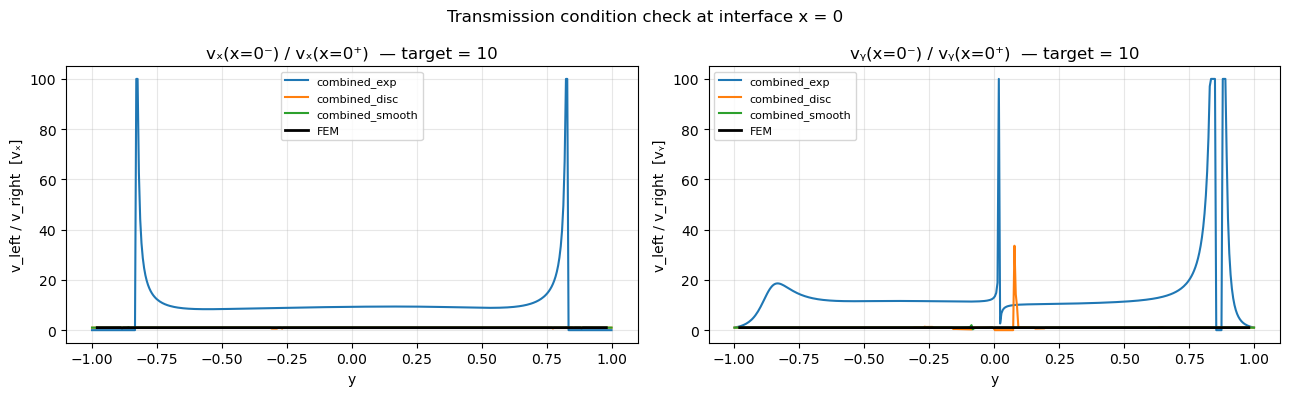

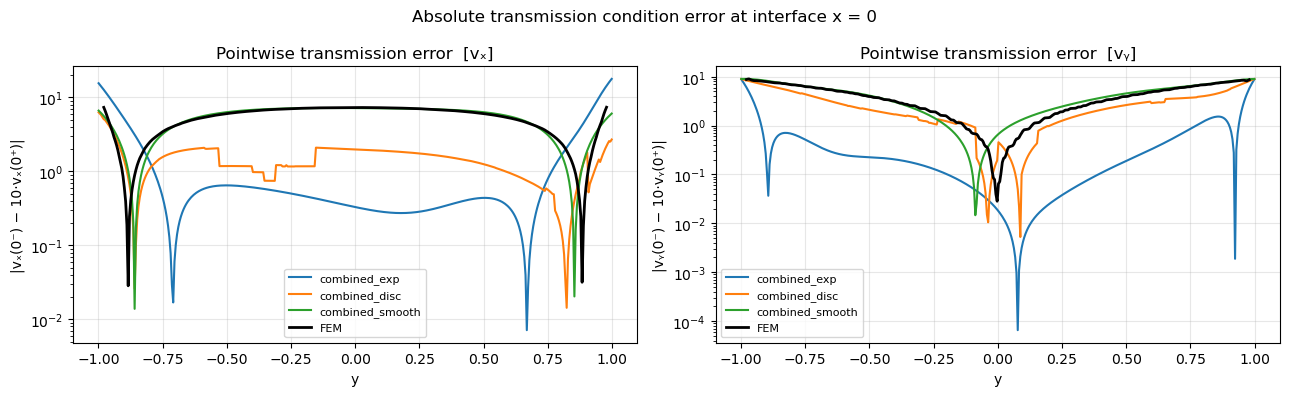

In [116]:
# ── Transmission condition test: v(x=0-) = (k_1/k_2) · v(x=0+) ──────────────
# The physical transmission condition at the interface x=0 is:
#   k_left * ∂_x u |_{0⁻}  =  k_right * ∂_x u |_{0⁺}
# which in mixed form reads:   v(0⁻) = (k_left/k_right) · v(0⁺)
# With k_left=10, k_right=1  →  ratio = 10.

K_1 = 10.0   # permeability on x < 0  (left)
K_2 = 1.0    # permeability on x >= 0 (right)
RATIO = K_1 / K_2  # expected v_left / v_right = 10

eps   = 1e-4        # tiny offset from the interface
N_pts = 400         # sample points along y ∈ (-1, 1)

y_vals  = torch.linspace(-1.0 + 1e-3, 1.0 - 1e-3, N_pts, device=device)
x_right = torch.stack([torch.full_like(y_vals,  eps), y_vals], dim=1)   # (N,2)  x=0+
x_left  = torch.stack([torch.full_like(y_vals, -eps), y_vals], dim=1)   # (N,2)  x=0-
y_np    = y_vals.cpu().numpy()

print(f"Transmission condition: v(x=0⁻) = (k_left/k_right) · v(x=0⁺)"
      f"   [ratio = {RATIO:.0f}]")
print(f"ε = {eps},  N_pts = {N_pts}\n")

header = f"{'Model':<20}  {'vx: mean |Δ|':>14}  {'vx: max |Δ|':>14}  {'vy: mean |Δ|':>14}  {'vy: max |Δ|':>14}"
print(header)
print("-" * len(header))

results = {}

# ── PINN models ───────────────────────────────────────────────────────────────
for name, model in models_named.items():
    model.eval()
    with torch.no_grad():
        v_r = model(x_right)[:, 1:]   # (N, 2)  x=0+
        v_l = model(x_left )[:, 1:]   # (N, 2)  x=0-

    diff_x = (v_l[:, 0] - RATIO * v_r[:, 0]).abs().cpu()
    diff_y = (v_l[:, 1] - RATIO * v_r[:, 1]).abs().cpu()
    results[name] = dict(v_r=v_r.cpu().numpy(), v_l=v_l.cpu().numpy(),
                         diff_x=diff_x.numpy(), diff_y=diff_y.numpy())
    print(f"{name:<20}  {diff_x.mean().item():>14.4e}  {diff_x.max().item():>14.4e}"
          f"  {diff_y.mean().item():>14.4e}  {diff_y.max().item():>14.4e}")

# ── FEM reference ─────────────────────────────────────────────────────────────
from scipy.interpolate import LinearNDInterpolator as LNDInterp

_interp_vx = LNDInterp(xy_np, v_fem_np[:, 0])
_interp_vy = LNDInterp(xy_np, v_fem_np[:, 1])

x_right_np = x_right.cpu().numpy()
x_left_np  = x_left.cpu().numpy()

fem_vr_x = _interp_vx(x_right_np);  fem_vr_y = _interp_vy(x_right_np)
fem_vl_x = _interp_vx(x_left_np);   fem_vl_y = _interp_vy(x_left_np)

fem_diff_x = np.abs(fem_vl_x - RATIO * fem_vr_x)
fem_diff_y = np.abs(fem_vl_y - RATIO * fem_vr_y)

results["FEM"] = dict(
    v_r=np.stack([fem_vr_x, fem_vr_y], axis=1),
    v_l=np.stack([fem_vl_x, fem_vl_y], axis=1),
    diff_x=fem_diff_x, diff_y=fem_diff_y,
)
print(f"{'FEM':<20}  {np.nanmean(fem_diff_x):>14.4e}  {np.nanmax(fem_diff_x):>14.4e}"
      f"  {np.nanmean(fem_diff_y):>14.4e}  {np.nanmax(fem_diff_y):>14.4e}")

# ── Plot: ratio v_left / v_right along the interface ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axvx, axvy = axes

styles = {"FEM": dict(color="black", linewidth=2.0, linestyle="-")}

for name, d in results.items():
    kw = styles.get(name, {})
    ratio_x = np.clip(d["v_l"][:, 0] / (d["v_r"][:, 0] + 1e-12), 0, 100)
    ratio_y = np.clip(d["v_l"][:, 1] / (d["v_r"][:, 1] + 1e-12), 0, 100)
    axvx.plot(y_np, ratio_x, label=name, **kw)
    axvy.plot(y_np, ratio_y, label=name, **kw)

for ax, comp in zip(axes, ["vₓ", "vᵧ"]):
    ax.set_xlabel("y")
    ax.set_ylabel(f"v_left / v_right  [{comp}]")
    ax.set_title(f"{comp}(x=0⁻) / {comp}(x=0⁺)  — target = {RATIO:.0f}")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("Transmission condition check at interface x = 0", fontsize=12)
plt.tight_layout()

plt.savefig("./images_hs/model_flux_ratio_contact.png")
plt.show()

# ── Plot: absolute error |v_left - ratio * v_right| along the interface ───────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axvx, axvy = axes

for name, d in results.items():
    kw = styles.get(name, {})
    axvx.plot(y_np, d["diff_x"], label=name, **kw)
    axvy.plot(y_np, d["diff_y"], label=name, **kw)

for ax, comp in zip(axes, ["vₓ", "vᵧ"]):
    ax.set_xlabel("y")
    ax.set_ylabel(f"|{comp}(0⁻) − {RATIO:.0f}·{comp}(0⁺)|")
    ax.set_title(f"Pointwise transmission error  [{comp}]")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_yscale("log")

plt.suptitle("Absolute transmission condition error at interface x = 0", fontsize=12)
plt.tight_layout()
plt.savefig("./images_hs/model_flux_ratio_error.png")

plt.show()
